# Stock Price Prediction Analysis (Simple Walkthrough)

This notebook demonstrates a complete stock price prediction pipeline using LSTM and GRU models.

## Workflow Overview
1. Import required libraries
2. Load and inspect stock price data
3. Visualize key market trends
4. Prepare time-series sequences and scale features safely
5. Build and train LSTM and GRU models
6. Evaluate model performance and visualize results

## Step 1: Import Libraries

Load all dependencies used for data handling, visualization, preprocessing, modeling, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# # Set plot style
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("husl")


## Step 2: Load the Data

Download Adani Ports stock data from Yahoo Finance for the selected date range, then check its structure and quality.

In [2]:
# Import yfinance for downloading stock data
import yfinance as yf

# Download Adani Ports data from Yahoo Finance
ticker = "ADANIPORTS.NS"
start_date = "2021-03-28"
end_date = "2026-03-28"

print(f"Downloading {ticker} data from Yahoo Finance...")
df = yf.download(ticker, start=start_date, end=end_date)

# Flatten MultiIndex columns (newer yfinance versions)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
    
    # Rename columns for easier access
    df.rename(columns={
        'Close_ADANIPORTS.NS': 'Close',
        'Open_ADANIPORTS.NS': 'Open', 
        'High_ADANIPORTS.NS': 'High',
        'Low_ADANIPORTS.NS': 'Low',
        'Volume_ADANIPORTS.NS': 'Volume'
    }, inplace=True)

# Reset index to make Date a column
df.reset_index(inplace=True)

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Display first few rows
print("\nFirst 5 rows of the data:")
df.head()


[*********************100%***********************]  1 of 1 completed


First 5 rows of the data:


,Close,High,Low,Open,Volume
Date,,,,,
2021-03-30,689.743164,696.975020,676.881160,682.462784,9109273
2021-03-31,681.831909,698.819463,678.143136,684.355751,7752226
2021-04-01,714.690735,720.272360,684.355814,692.606912,15017049
2021-04-05,720.515015,723.184488,694.062965,710.322482,15622924
2021-04-06,811.082886,827.730712,721.243005,733.862331,64555516


In [3]:
# Check data info
print("\nData Information:")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")



Data Information:
Shape: (1236, 5)

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing values:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
# Basic statistics
print("\nStatistical Summary:")
df.describe()



Statistical Summary:


,Close,High,Low,Open,Volume
count,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,1017.986080,1033.057941,1004.147551,1019.900044,6.444519e+06
std,316.754664,318.869137,314.626066,317.169819,9.400372e+06
min,455.184845,499.034926,388.892904,451.789016,0.000000e+00
25%,727.237991,736.853042,718.605363,728.197692,2.258730e+06
50%,858.989685,874.246229,845.399029,859.038958,3.710298e+06
75%,1354.515778,1372.454487,1334.044864,1354.151770,6.655277e+06
max,1582.451172,1606.656410,1560.905968,1575.900024,1.155175e+08


## Step 3: Visualize the Stock Data

Plot the closing price trend and OHLC movement to understand overall market behavior before modeling.

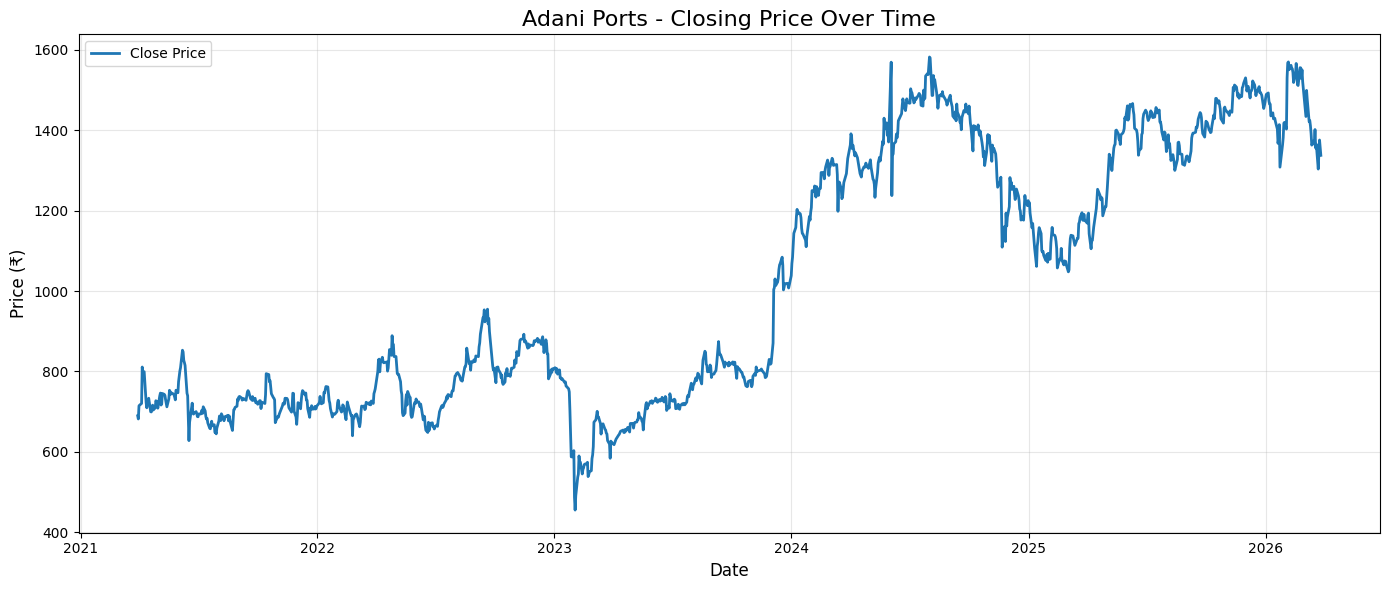

In [5]:
# Plot closing prices over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.title('Adani Ports - Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


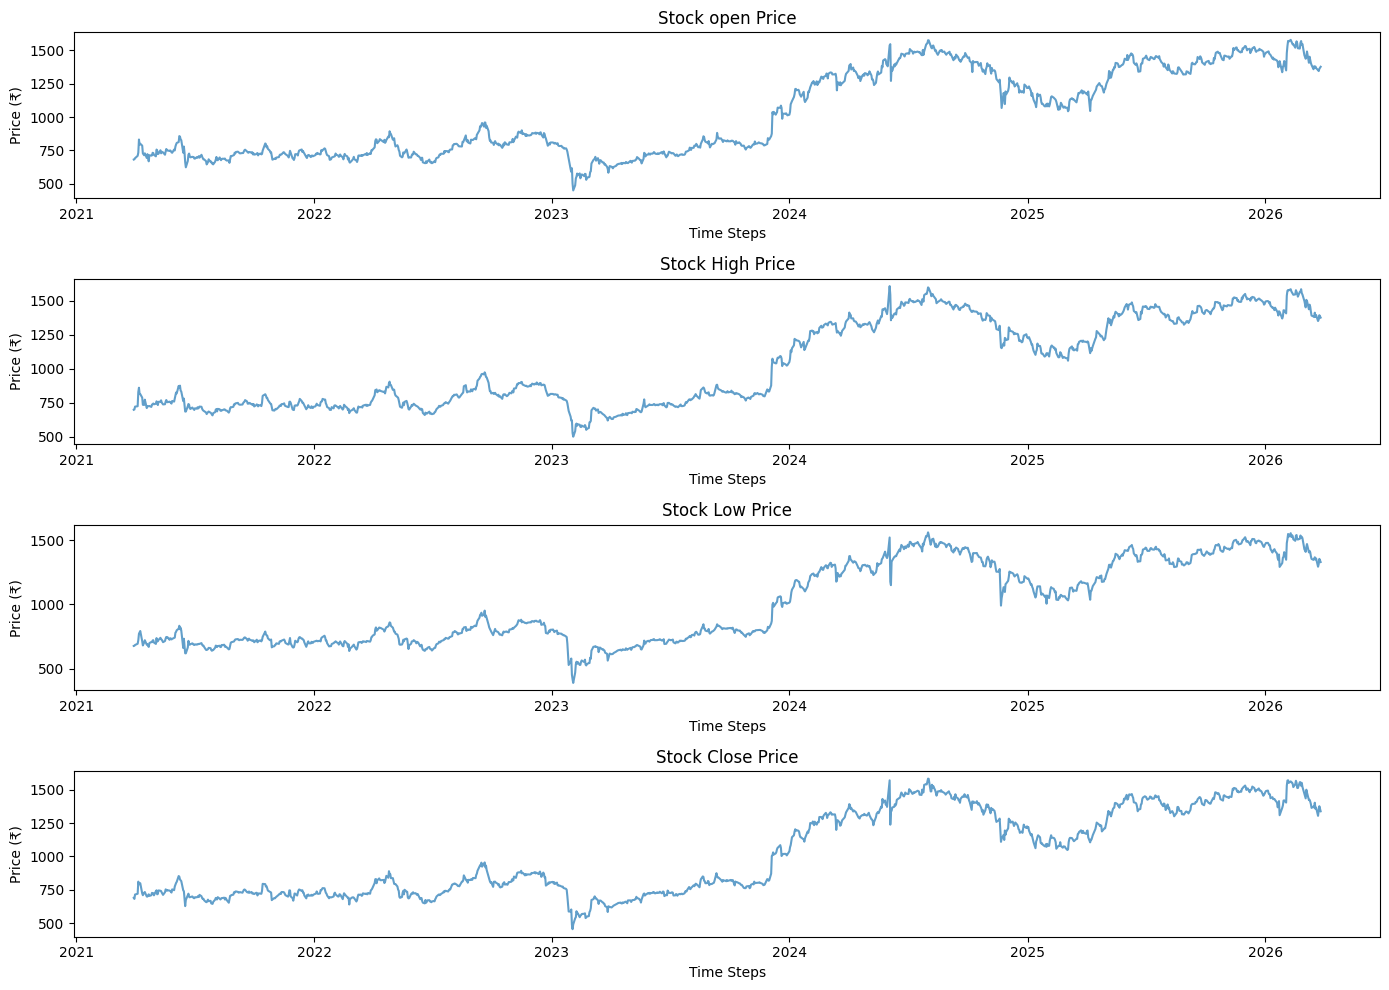

In [6]:
# Plot all OHLC data
fig,axes =plt.subplots(4,1,figsize=(14,10))

axes[0].plot(df.index, df['Open'], label='Open', alpha=0.7)
axes[0].set_title("Stock open Price")
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price (₹)')

axes[1].plot(df.index, df['High'], label='High', alpha=0.7)
axes[1].set_title("Stock High Price")
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Price (₹)')

axes[2].plot(df.index, df['Low'], label='Low', alpha=0.7)
axes[2].set_title("Stock Low Price")
axes[2].set_xlabel('Time Steps')
axes[2].set_ylabel('Price (₹)')

axes[3].plot(df.index, df['Close'], label='Close', alpha=0.7)
axes[3].set_title("Stock Close Price")
axes[3].set_xlabel('Time Steps')
axes[3].set_ylabel('Price (₹)')

plt.tight_layout()
plt.show()


## Step 4: Prepare the Data for Training

This stage includes:
1. Handling missing values
2. Defining feature and target columns
3. Creating rolling sequences for time-series prediction
4. Performing leakage-safe train/test split (shuffle=False)
5. Scaling features and target using training data only

In [7]:
# Handle missing values - forward fill then backward fill
df_clean = df.fillna(method='ffill').fillna(method='bfill')

# Check if any missing values remain
print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")


Missing values after cleaning: 0


In [8]:
# Select features to use for prediction
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
data = df_clean[feature_columns].values

print(f"Data shape: {data.shape}")
print(f"Close price range: ₹{data[:, 3].min():.2f} - ₹{data[:, 3].max():.2f}")


Data shape: (1236, 5)
Close price range: ₹455.18 - ₹1582.45


In [9]:
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

feature_data = df[feature_columns].to_numpy()
target_data = df[["Close"]].to_numpy()
target_idx = feature_columns.index("Close")

In [10]:
feature_data.shape , target_data.shape

((1236, 5), (1236, 1))

In [11]:
target_data


array([[ 689.74316406],
       [ 681.83190918],
       [ 714.69073486],
       ...,
       [1344.19995117],
       [1375.90002441],
       [1337.80004883]])

In [12]:
data[1:1+10]

array([[6.84355751e+02, 6.98819463e+02, 6.78143136e+02, 6.81831909e+02,
        7.75222600e+06],
       [6.92606912e+02, 7.20272360e+02, 6.84355814e+02, 7.14690735e+02,
        1.50170490e+07],
       [7.10322482e+02, 7.23184488e+02, 6.94062965e+02, 7.20515015e+02,
        1.56229240e+07],
       [7.33862331e+02, 8.27730712e+02, 7.21243005e+02, 8.11082886e+02,
        6.45555160e+07],
       [8.31904712e+02, 8.59084796e+02, 7.71720240e+02, 7.90891907e+02,
        9.77178800e+07],
       [7.94046804e+02, 8.13461151e+02, 7.82398195e+02, 7.98900391e+02,
        3.40258730e+07],
       [8.00599137e+02, 8.12490424e+02, 7.93124601e+02, 7.99482788e+02,
        2.18047850e+07],
       [7.86184036e+02, 7.86184036e+02, 7.13477280e+02, 7.22844727e+02,
        2.81122400e+07],
       [7.28038051e+02, 7.33619676e+02, 6.80812626e+02, 7.09642944e+02,
        5.28125170e+07],
       [7.14350928e+02, 7.32406247e+02, 7.03770085e+02, 7.28377747e+02,
        2.61086140e+07]])

In [13]:
data[1:1+10,0]

array([684.35575066, 692.6069125 , 710.3224816 , 733.8623309 ,
       831.90471197, 794.0468038 , 800.59913674, 786.18403612,
       728.03805094, 714.35092814])

In [14]:

SEQUENCE_LENGTH = 100

X = []
y = []

# Close price is at index 3 in our feature_columns
CLOSE_INDEX = 3

for i in range(len(data)-SEQUENCE_LENGTH):
    
    X.append(data[i:i+SEQUENCE_LENGTH]) # Get the sequence of past days
    
    y.append(data[i + SEQUENCE_LENGTH][CLOSE_INDEX]) # Get the next day's close price

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")  # (samples, timesteps, features)
print(f"y shape: {y.shape}")  # (samples,)


X shape: (1136, 100, 5)
y shape: (1136,)


In [15]:
X_train_raw,X_test_raw,y_train_raw,y_test_raw=train_test_split(X,y,test_size=0.2,shuffle=False,random_state=42)

print(f"Training set size: {len(X_train_raw)}")
print(f"Testing set size: {len(X_test_raw)}")


Training set size: 908
Testing set size: 228


In [16]:
X_train_raw.shape , y_train_raw.shape

((908, 100, 5), (908,))

In [17]:
# NOW normalize - fit scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))


In [18]:
# Reshape for scaling: (samples, timesteps, features) -> (samples*timesteps, features)
n_train_samples, n_timesteps, n_features = X_train_raw.shape
n_test_samples = X_test_raw.shape[0]

# Fit scaler on training data only
X_train_reshaped = X_train_raw.reshape(-1, n_features)
scaler.fit(X_train_reshaped)

MinMaxScaler()

In [19]:
# Transform both train and test using the SAME scaler (fit on train only!)
X_train = scaler.transform(X_train_reshaped).reshape(n_train_samples, n_timesteps, n_features)
X_test = scaler.transform(X_test_raw.reshape(-1, n_features)).reshape(n_test_samples, n_timesteps, n_features)


In [20]:
# Scale y values with a dedicated scaler (fit on train only)
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train = y_scaler.fit_transform(y_train_raw.reshape(-1, 1)).reshape(-1)
y_test = y_scaler.transform(y_test_raw.reshape(-1, 1)).reshape(-1)

In [21]:
print(X_train.shape)
print(y_train.shape)

(908, 100, 5)
(908,)


In [22]:
print(X_test.shape)
print(y_test.shape)

(228, 100, 5)
(228,)


## Step 5: Build the LSTM Model

Create a stacked LSTM network for sequence learning and compile it with regression-friendly loss and optimizer settings.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

# Create LSTM model architecture
lstm_model = Sequential()

# First LSTM layer 
lstm_model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

# Second LSTM layer 
lstm_model.add(LSTM(units=100,return_sequences=True))

# 3rd LSTM layer
lstm_model.add(LSTM(units=50,return_sequences=False))

# Output layer
lstm_model.add(Dense(units=1))

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 100)       │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,051 (597.86 KB)

 Trainable params: 153,051 (597.86 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the LSTM Model

Train the LSTM with early stopping, generate predictions, and compute core evaluation metrics.

In [24]:
# Set training parameters
EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 15  # Early stopping patience

# Create callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)

# Train the model
print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("\nLSTM training completed!")


Training LSTM model...
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0343 - val_loss: 0.0064
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0053 - val_loss: 0.0029
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_loss: 0.0024
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0021 - val_loss: 0.0029
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 0.0024
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0020 - val_loss: 0.0033
Epoch 12/100
15/15 ━━━━━━━━━━

In [25]:
X_train_lstm_predictions = lstm_model.predict(X_train)
X_test_lstm_predictions = lstm_model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [26]:
train_predict_LSTM=y_scaler.inverse_transform(X_train_lstm_predictions)
test_predict_LSTM=y_scaler.inverse_transform(X_test_lstm_predictions)


In [27]:
X_train_raw.reshape(-1).shape,train_predict_LSTM.shape

((454000,), (908, 1))

In [28]:
pd.DataFrame({
    "Actual_Train": y_train_raw,  # Use y_train instead of X_train_raw
    "Train_predict": train_predict_LSTM.reshape(-1) # Flattens to (908,)
})


,Actual_Train,Train_predict
0,704.546143,672.687317
1,705.474731,684.822388
2,710.655518,703.018433
3,713.588135,716.772705
4,731.476685,723.845337
...,...,...
903,1233.100708,1239.938721
904,1230.413818,1231.272339
905,1187.223999,1228.804443
906,1204.042114,1204.345703


In [29]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test, X_test_lstm_predictions))
lstm_mae = mean_absolute_error(y_test, X_test_lstm_predictions)
lstm_r2 = r2_score(y_test, X_test_lstm_predictions)

# Create comparison table
comparison_df_lstm = pd.DataFrame({
    'Model': ['LSTM'],
    'RMSE': [lstm_rmse],
    'MAE': [lstm_mae],
    'R² Score': [lstm_r2]
})
comparison_df_lstm

,Model,RMSE,MAE,R² Score
0,LSTM,0.023672,0.017531,0.838048


In [30]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_raw, test_predict_LSTM))
lstm_mae = mean_absolute_error(y_test_raw, test_predict_LSTM)
lstm_r2 = r2_score(y_test_raw, test_predict_LSTM)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['LSTM'],
    'RMSE': [lstm_rmse],
    'MAE': [lstm_mae],
    'R² Score': [lstm_r2]
})
comparison_df

,Model,RMSE,MAE,R² Score
0,LSTM,26.684104,19.762132,0.838048


In [31]:
# Create a dataframe for comparison
predictions_df_LSTM = pd.DataFrame({
    'Actual': y_test,
    'LSTM_Prediction': X_test_lstm_predictions.flatten(),
})

print("Predictions sample:")
predictions_df_LSTM.head(10)

Predictions sample:


,Actual,LSTM_Prediction
0,0.670139,0.662252
1,0.711278,0.668068
2,0.785434,0.699345
3,0.762216,0.752251
4,0.777577,0.772484
5,0.773074,0.773309
6,0.749415,0.775010
7,0.798676,0.755813
8,0.804944,0.778964
9,0.807239,0.791109


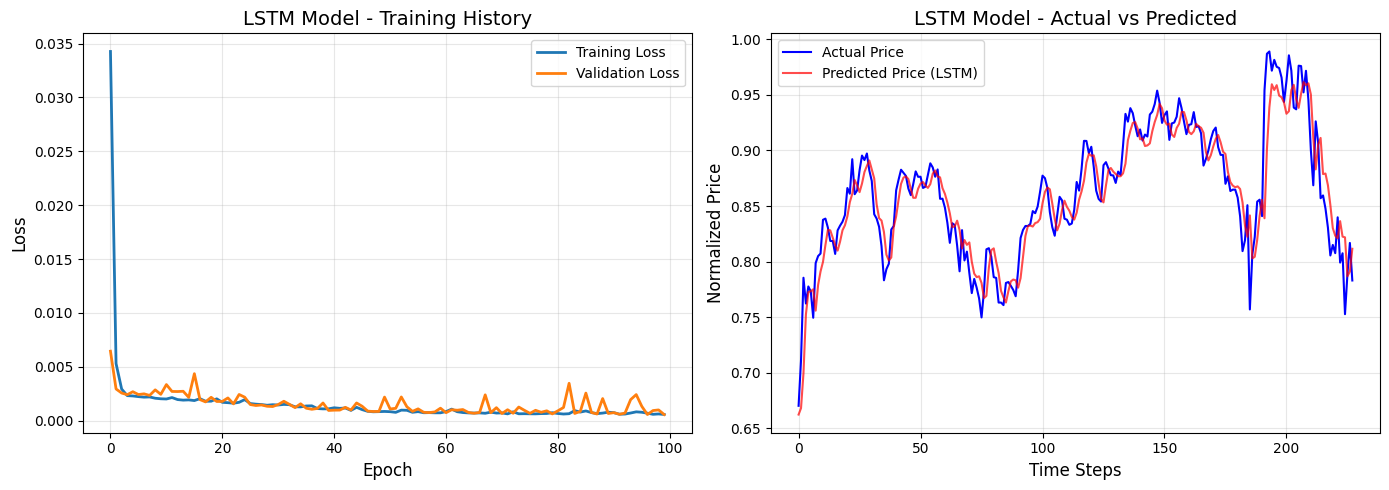

In [32]:
# Plot training history for LSTM
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(X_test_lstm_predictions.flatten(), label='Predicted Price (LSTM)', color='red', alpha=0.7)
plt.title('LSTM Model - Actual vs Predicted', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

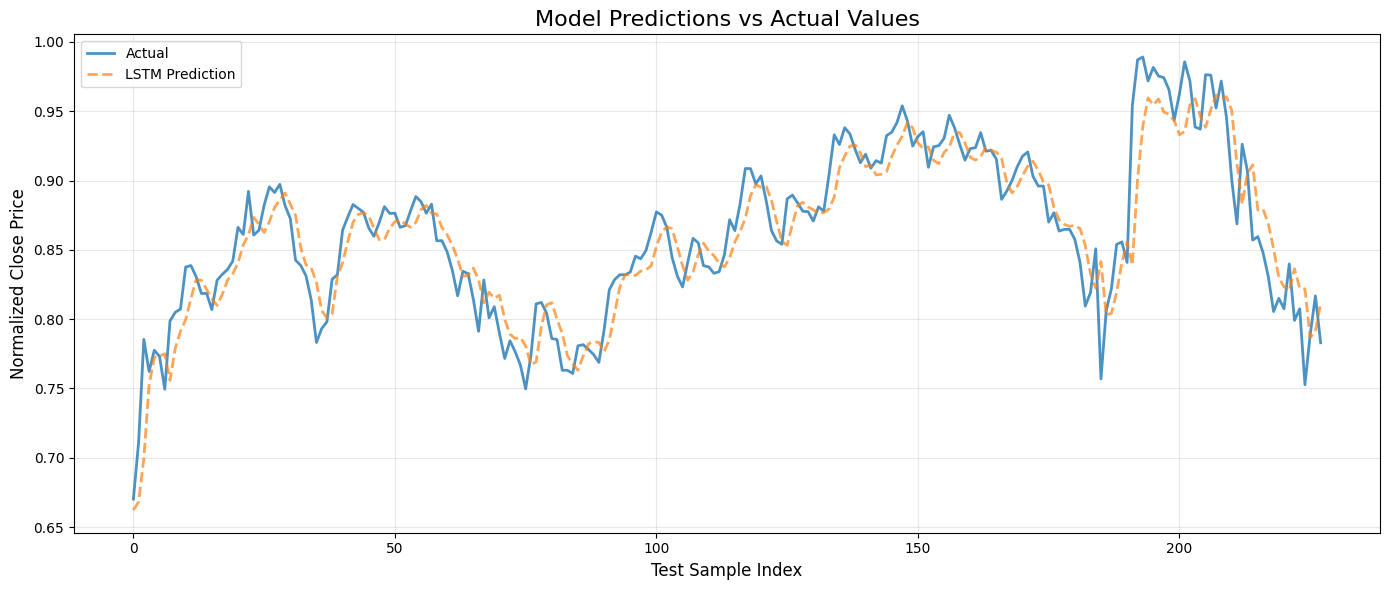

In [33]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))

plt.plot(predictions_df_LSTM.index, predictions_df_LSTM['Actual'], label='Actual', linewidth=2, alpha=0.8)
plt.plot(predictions_df_LSTM.index, predictions_df_LSTM['LSTM_Prediction'], label='LSTM Prediction', linewidth=2, alpha=0.7, linestyle='--')
plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Normalized Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [34]:
scaler_for_prices = y_scaler          # dedicated scaler for the target variable
length_of_sequence = SEQUENCE_LENGTH  
past_data = X_test                    # testing dataset (scaled)
close_idx = CLOSE_INDEX               # From notebook (Close index = 3)

# Grab the VERY LAST sequence available from X_test to act as our launching pad
current_window = past_data[-1].copy() 

# List to store future predictions
predicted_prices_list = []
days_to_guess = 7

# --- STEP 2: THE RECURSIVE PREDICTION LOOP ---
for i in range(days_to_guess):
    
    # 1. Reshape window for the model: (1 batch, 100 timesteps, 5 features)
    input_for_model = current_window.reshape(1, length_of_sequence, -1)
    
    # 2. Get the raw (scaled) prediction from the LSTM
    raw_prediction = lstm_model.predict(input_for_model, verbose=0)
    
    # 3. Inverse transform directly (Works because y_scaler was fit on 1 feature)
    real_price = scaler_for_prices.inverse_transform(raw_prediction).reshape(-1)[0]
    predicted_prices_list.append(real_price)
    
    # 4. Update the sliding window
    # Copy the features of the last day in the window
    last_row = current_window[-1].copy()
    
    # Overwrite the 'Close' feature with our new raw prediction
    last_row[close_idx] = raw_prediction.reshape(-1)[0]
    
    # Shift window: drop the oldest day (index 0) and append our newly constructed day
    current_window = np.vstack([current_window[1:], last_row.reshape(1, -1)])

# --- STEP 3: GENERATE FUTURE BUSINESS DATES ---
# Find the exact last date in your original dataframe
last_known_date = df.index[-1]

# Generate the next 7 'Business' days (skipping weekends)
future_dates = pd.date_range(start=last_known_date + timedelta(days=1), 
                             periods=days_to_guess, 
                             freq='B')

# --- STEP 4: DISPLAY RESULTS ---
results_table = pd.DataFrame({
    'Date': future_dates.strftime('%Y-%m-%d'), # Clean date formatting
    'Predicted_Close_Price ($)': np.round(predicted_prices_list, 2) # Round to 2 decimal places
})

print(f"\n--- LSTM Predictions for the Next {days_to_guess} Business Days ---")
print(results_table.to_string(index=False))



--- LSTM Predictions for the Next 7 Business Days ---
      Date  Predicted_Close_Price ($)
2026-03-30                1369.969971
2026-03-31                1376.040039
2026-04-01                1379.089966
2026-04-02                1378.920044
2026-04-03                1377.219971
2026-04-06                1374.930054
2026-04-07                1372.689941


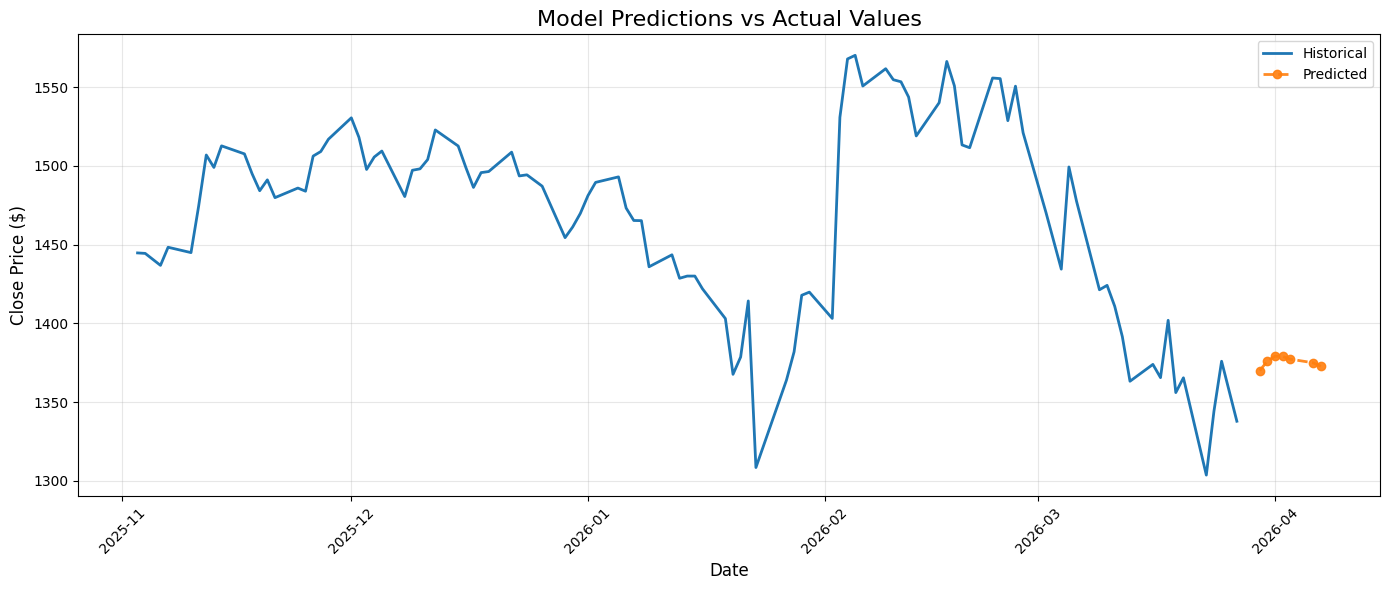

In [35]:
# Visualize future predictions
plt.figure(figsize=(14, 6))

# Plot last 100 days of historical data
historical_close = df_clean['Close'].values[-100:]
historical_dates = df_clean.index[-100:]

# Historical data
plt.plot(historical_dates, historical_close, label='Historical', linewidth=2, alpha=1)

# ----------------- FIXED SECTION -----------------
# Ensure Dates are datetime objects
results_table['Date'] = pd.to_datetime(results_table['Date'])

# Plot Predictions
plt.plot(results_table['Date'], results_table['Predicted_Close_Price ($)'], 
         label='Predicted', linewidth=2, alpha=0.9, linestyle='--', marker='o')
# -------------------------------------------------

plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 7: Build the GRU Model

Create a stacked GRU network as a lighter recurrent alternative to LSTM.

In [36]:
from tensorflow.keras.layers import GRU

# Create GRU model architecture
gru_model = Sequential()

# First GRU layer 
gru_model.add(GRU(units=100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))

# Second GRU layer 
gru_model.add(GRU(units=100,return_sequences=True))

# 3rd GRU layer
gru_model.add(GRU(units=50,return_sequences=False))

# Output layer
gru_model.add(Dense(units=1))

# Compile the model
gru_model.compile(optimizer='adam', loss='mean_squared_error')

# Display model summary
gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 100, 100)       │        32,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 100)       │        60,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 50)             │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,551 (451.37 KB)

 Trainable params: 115,551 (451.37 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train the GRU Model

Train the GRU model with the same configuration pattern and monitor validation performance.

In [37]:
# Set training parameters
EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 15  # Early stopping patience

# Create callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1)


# Train the GRU model
print("Training GRU model...")
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

print("\nGRU training completed!")


Training GRU model...
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0444 - val_loss: 0.0320
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0043 - val_loss: 0.0127
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012 - val_loss: 9.0410e-04
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.7490e-04 - val_loss: 8.7948e-04
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 9.3119e-04 - val_loss: 8.7991e-04
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.9528e-04 - val_loss: 8.0530e-04
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.6464e-04 - val_loss: 8.7014e-04
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.4309e-04 - val_loss: 8.7954e-04
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.1128e-04 - val_loss: 6.7501e-04
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.99

## Step 9: Make Predictions and Evaluate GRU

Generate GRU predictions, inverse-transform outputs to original price scale, and compute evaluation metrics.

In [38]:
X_train_GRU_predictions = gru_model.predict(X_train)
X_test_GRU_predictions = gru_model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [39]:
train_predict_GRU=y_scaler.inverse_transform(X_train_GRU_predictions)
test_predict_GRU=y_scaler.inverse_transform(X_test_GRU_predictions)

In [40]:
# Calculate evaluation metrics for GRU
gru_rmse = np.sqrt(mean_squared_error(y_test, X_test_GRU_predictions))
gru_mae = mean_absolute_error(y_test, X_test_GRU_predictions)
gru_r2 = r2_score(y_test, X_test_GRU_predictions)

# Create comparison table
comparison_df_gru = pd.DataFrame({
    'Model': ['GRU'],
    'RMSE': [gru_rmse],
    'MAE': [gru_mae],
    'R² Score': [gru_r2]
})
comparison_df_gru

,Model,RMSE,MAE,R² Score
0,GRU,0.021273,0.015023,0.869207


In [41]:
# Create a dataframe for comparison
predictions_df_GRU = pd.DataFrame({
    'Actual': y_test,
    'GRU_Prediction': X_test_GRU_predictions.flatten(),
})

print("Predictions sample:")
predictions_df_GRU.head(10)

Predictions sample:


,Actual,GRU_Prediction
0,0.670139,0.668545
1,0.711278,0.670754
2,0.785434,0.715419
3,0.762216,0.783076
4,0.777577,0.771774
5,0.773074,0.775677
6,0.749415,0.778437
7,0.798676,0.752863
8,0.804944,0.796354
9,0.807239,0.806780


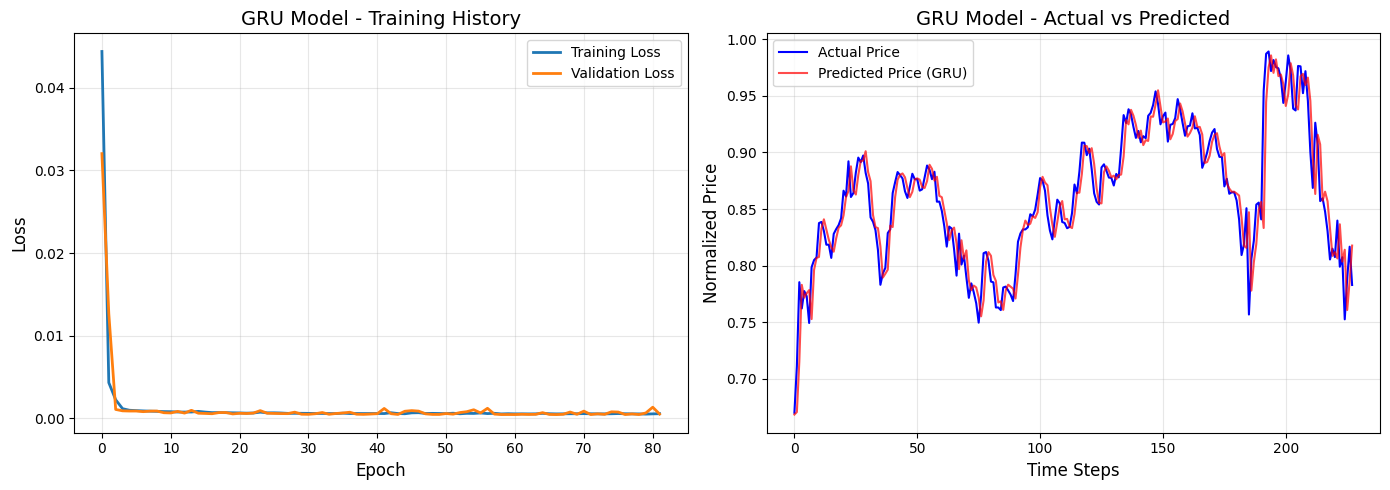

In [42]:
# Plot training history for GRU
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(gru_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(gru_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('GRU Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(X_test_GRU_predictions.flatten(), label='Predicted Price (GRU)', color='red', alpha=0.7)
plt.title('GRU Model - Actual vs Predicted', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

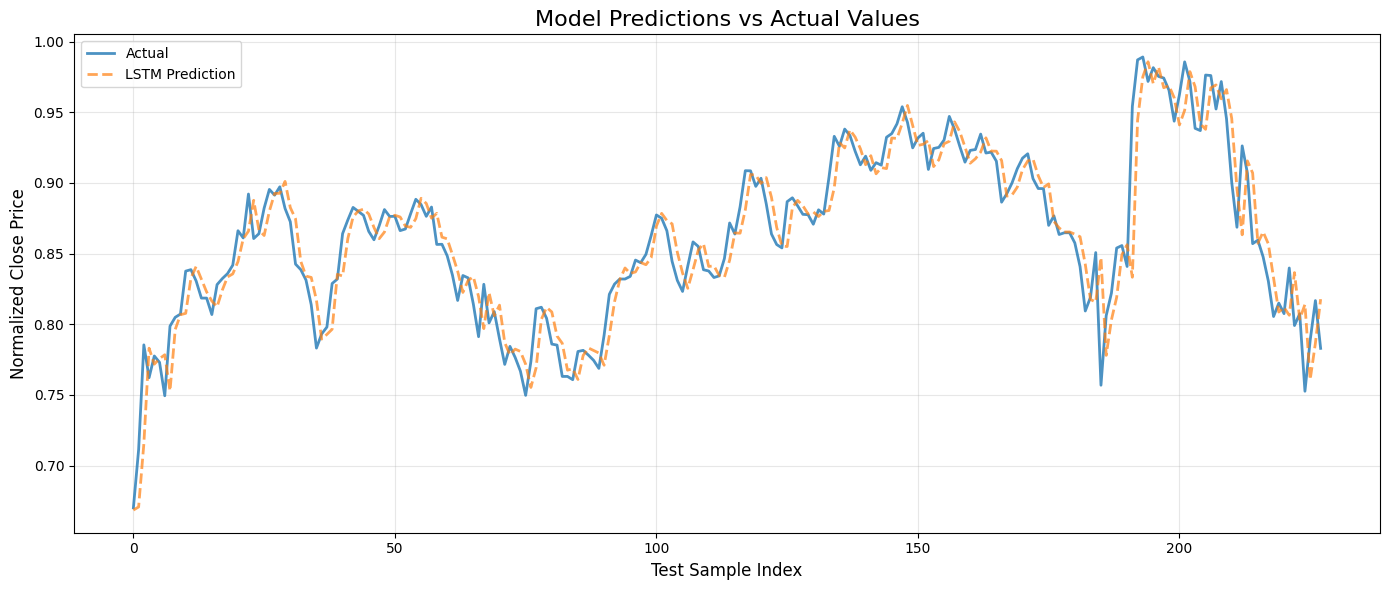

In [43]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))

plt.plot(predictions_df_GRU.index, predictions_df_GRU['Actual'], label='Actual', linewidth=2, alpha=0.8)
plt.plot(predictions_df_GRU.index, predictions_df_GRU['GRU_Prediction'], label='LSTM Prediction', linewidth=2, alpha=0.7, linestyle='--')
plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Normalized Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [44]:
scaler_for_prices = y_scaler          # dedicated scaler for the target variable
length_of_sequence = SEQUENCE_LENGTH  
past_data = X_test                    # testing dataset (scaled)
close_idx = CLOSE_INDEX               # From notebook (Close index = 3)

# Grab the VERY LAST sequence available from X_test to act as our launching pad
current_window = past_data[-1].copy() 

# List to store future predictions
predicted_prices_list = []
days_to_guess = 7

# --- STEP 2: THE RECURSIVE PREDICTION LOOP ---
for i in range(days_to_guess):
    
    # 1. Reshape window for the model: (1 batch, 100 timesteps, 5 features)
    input_for_model = current_window.reshape(1, length_of_sequence, -1)
    
    # 2. Get the raw (scaled) prediction from the LSTM
    raw_prediction = gru_model.predict(input_for_model, verbose=0)
    
    # 3. Inverse transform directly (Works because y_scaler was fit on 1 feature)
    real_price = scaler_for_prices.inverse_transform(raw_prediction).reshape(-1)[0]
    predicted_prices_list.append(real_price)
    
    # 4. Update the sliding window
    # Copy the features of the last day in the window
    last_row = current_window[-1].copy()
    
    # Overwrite the 'Close' feature with our new raw prediction
    last_row[close_idx] = raw_prediction.reshape(-1)[0]
    
    # Shift window: drop the oldest day (index 0) and append our newly constructed day
    current_window = np.vstack([current_window[1:], last_row.reshape(1, -1)])

# --- STEP 3: GENERATE FUTURE BUSINESS DATES ---
# Find the exact last date in your original dataframe
last_known_date = df.index[-1]

# Generate the next 7 'Business' days (skipping weekends)
future_dates = pd.date_range(start=last_known_date + timedelta(days=1), 
                             periods=days_to_guess, 
                             freq='B')

# --- STEP 4: DISPLAY RESULTS ---
results_table = pd.DataFrame({
    'Date': future_dates.strftime('%Y-%m-%d'), # Clean date formatting
    'Predicted_Close_Price ($)': np.round(predicted_prices_list, 2) # Round to 2 decimal places
})

print(f"\n--- LSTM Predictions for the Next {days_to_guess} Business Days ---")
print(results_table.to_string(index=False))



--- LSTM Predictions for the Next 7 Business Days ---
      Date  Predicted_Close_Price ($)
2026-03-30                1377.030029
2026-03-31                1378.709961
2026-04-01                1378.680054
2026-04-02                1377.650024
2026-04-03                1376.560059
2026-04-06                1375.709961
2026-04-07                1375.130005


## Step 10: Visualize Training History

Compare LSTM and GRU learning curves (training vs validation loss) to inspect convergence and overfitting behavior.

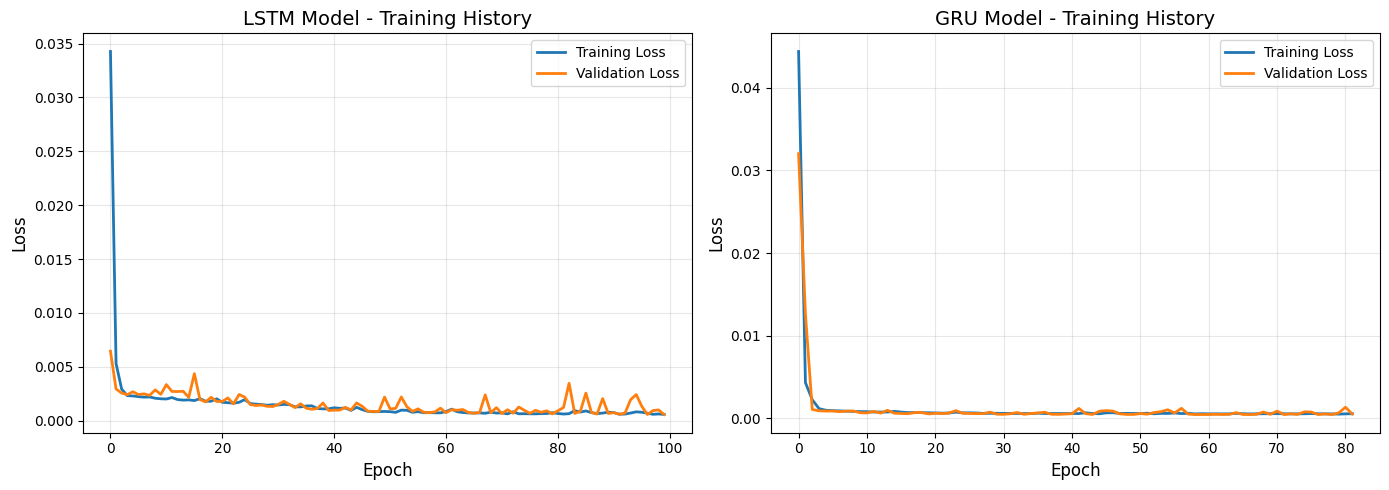

In [45]:
# Plot training history for LSTM
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(lstm_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training history for GRU
plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(gru_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('GRU Model - Training History', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 11: Visualize Predictions vs Actual Values

Overlay model predictions against actual values and inspect absolute prediction errors.

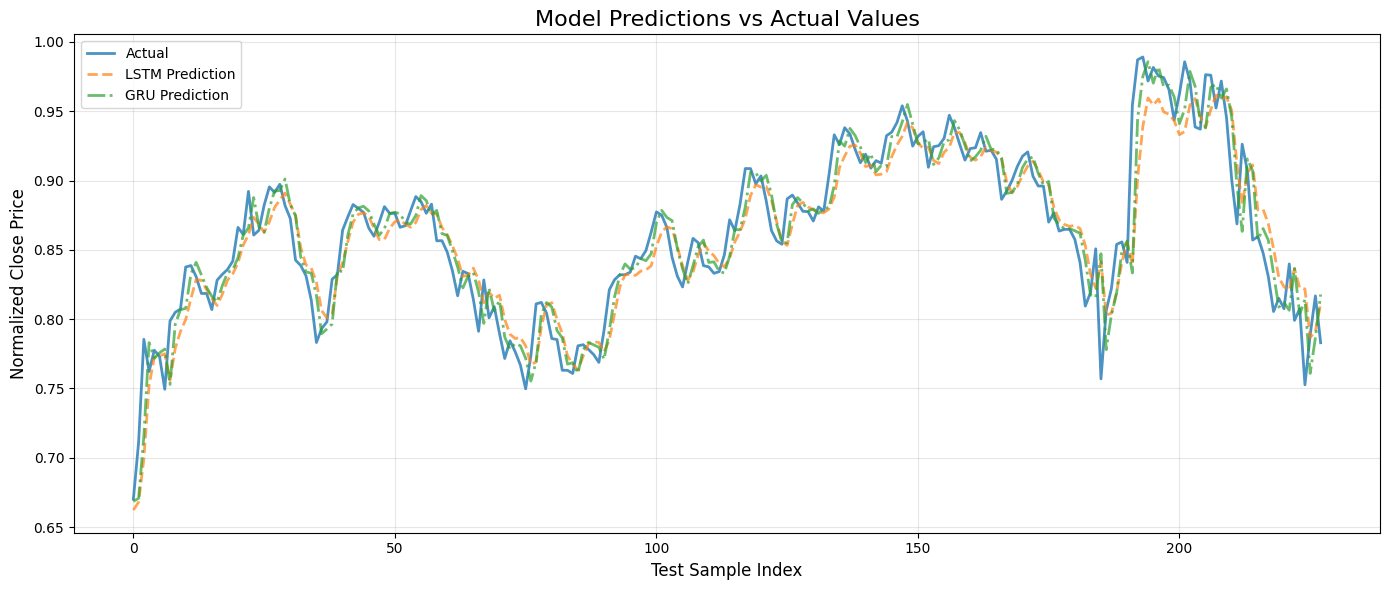

In [46]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))

plt.plot(predictions_df_GRU.index, predictions_df_GRU['Actual'], label='Actual', linewidth=2, alpha=0.8)
plt.plot(predictions_df_LSTM.index, predictions_df_LSTM['LSTM_Prediction'], label='LSTM Prediction', linewidth=2, alpha=0.7, linestyle='--')
plt.plot(predictions_df_GRU.index, predictions_df_GRU['GRU_Prediction'], label='GRU Prediction', linewidth=2, alpha=0.7, linestyle='-.')

plt.title('Model Predictions vs Actual Values', fontsize=16)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Normalized Close Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


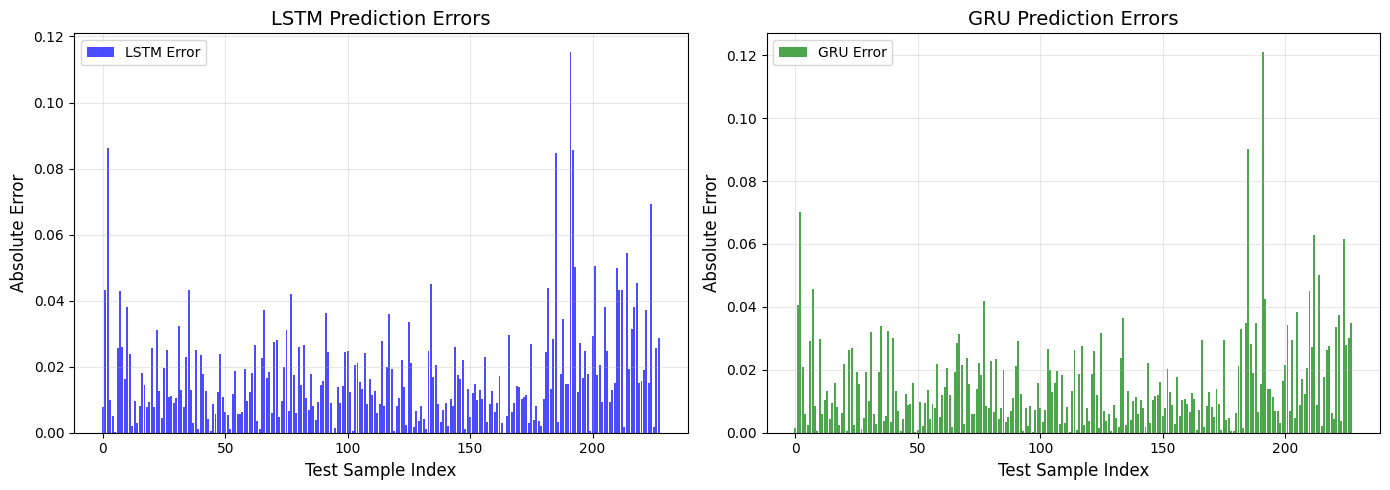

In [47]:
# Plot prediction errors
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
lstm_errors = np.abs(predictions_df_LSTM['Actual'] - predictions_df_LSTM['LSTM_Prediction'])
plt.bar(range(len(lstm_errors)), lstm_errors, alpha=0.7, color='blue', label='LSTM Error')
plt.title('LSTM Prediction Errors', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
gru_errors = np.abs(predictions_df_GRU['Actual'] - predictions_df_GRU['GRU_Prediction'])
plt.bar(range(len(gru_errors)), gru_errors, alpha=0.7, color='green', label='GRU Error')
plt.title('GRU Prediction Errors', fontsize=14)
plt.xlabel('Test Sample Index', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

This notebook:
1. Loaded and explored Adani Ports stock data
2. Preprocessed data with leakage-safe splitting and scaling
3. Built and trained both LSTM and GRU models
4. Evaluated performance using RMSE, MAE, and R2 score
5. Compared model behavior through multiple visualizations

### Key Takeaways
- Both LSTM and GRU can model time-series behavior effectively.
- GRU is often more computationally efficient, while LSTM can capture longer dependencies.
- Lower RMSE/MAE and higher R2 indicate stronger predictive performance.
- Early stopping helps reduce overfitting risk.

### End Note

You can rerun this notebook with a different ticker or time range to compare model behavior across stocks.